# Logistics Delivery Performance Analysis and Optimization

## Yuva Interns – Week 1 Task

This project analyzes e-commerce logistics data to evaluate
delivery performance, freight costs, product characteristics,
and geographic factors using Python.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
import pandas as pd

orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

print("All 5 datasets loaded successfully!")

All 5 datasets loaded successfully!


In [ ]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)
print("Sellers:", sellers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Customers: (99441, 5)
Sellers: (3095, 4)


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
print("DATA TYPES:")
print(orders.dtypes)

print("\nMISSING VALUES:")
print(orders.isnull().sum())

DATA TYPES:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

MISSING VALUES:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [ ]:
status_missing = orders.groupby("order_status").agg(
    total_orders=("order_id", "count")
)

status_missing["missing_carrier_date"] = (
    orders.groupby("order_status")["order_delivered_carrier_date"]
    .apply(lambda x: x.isna().sum())
)

status_missing["missing_customer_date"] = (
    orders.groupby("order_status")["order_delivered_customer_date"]
    .apply(lambda x: x.isna().sum())
)

status_missing

,total_orders,missing_carrier_date,missing_customer_date
order_status,,,
approved,2,2,2
canceled,625,550,619
created,5,5,5
delivered,96478,2,8
invoiced,314,314,314
processing,301,301,301
shipped,1107,0,1107
unavailable,609,609,609


In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [ ]:
delivered_missing = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

print("Number of delivered orders missing customer delivery date:",
      len(delivered_missing))

delivered_missing

Number of delivered orders missing customer delivery date: 8


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [ ]:
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

print("Total delivered orders:", len(delivered_orders))
print("Orders used for delivery analysis:", len(delivered_orders))

Total delivered orders: 96470
Orders used for delivery analysis: 96470


In [ ]:
delivered_orders["delivery_time_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)

average_delivery_time = delivered_orders["delivery_time_days"].mean()

print(f"Average Delivery Time: {average_delivery_time:.2f} days")

Average Delivery Time: 12.56 days


In [ ]:
delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

average_delay = delivered_orders["delivery_delay_days"].mean()

print(f"Average Delivery Delay: {average_delay:.2f} days")

Average Delivery Delay: -11.18 days


In [ ]:
delivered_orders["on_time"] = (
    delivered_orders["order_delivered_customer_date"]
    <= delivered_orders["order_estimated_delivery_date"]
)

on_time_rate = delivered_orders["on_time"].mean() * 100

print(f"On-Time Delivery Rate: {on_time_rate:.2f}%")

On-Time Delivery Rate: 91.89%


In [ ]:
order_freight = order_items.groupby("order_id", as_index=False).agg(
    total_freight=("freight_value", "sum"),
    total_product_value=("price", "sum")
)

print("Number of orders with freight data:", len(order_freight))
order_freight.head()

Number of orders with freight data: 98666


,order_id,total_freight,total_product_value
0,00010242fe8c5a6d1ba2dd792cb16214,13.29,58.90
1,00018f77f2f0320c557190d7a144bdd3,19.93,239.90
2,000229ec398224ef6ca0657da4fc703e,17.87,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.79,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,18.14,199.90


In [ ]:
average_freight = order_freight["total_freight"].mean()

print(f"Average Freight Cost per Order: {average_freight:.2f}")

Average Freight Cost per Order: 22.82


In [ ]:
total_freight = order_freight["total_freight"].sum()
total_product_value = order_freight["total_product_value"].sum()

freight_cost_ratio = (total_freight / total_product_value) * 100

print(f"Freight Cost Ratio: {freight_cost_ratio:.2f}%")

Freight Cost Ratio: 16.57%


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Average Delivery Time",
        "Average Delivery Delay",
        "On-Time Delivery Rate",
        "Average Freight Cost per Order",
        "Freight Cost Ratio"
    ],
    "Value": [
        f"{average_delivery_time:.2f} days",
        f"{average_delay:.2f} days",
        f"{on_time_rate:.2f}%",
        f"{average_freight:.2f}",
        f"{freight_cost_ratio:.2f}%"
    ]
})

kpi_summary

,KPI,Value
0,Average Delivery Time,12.56 days
1,Average Delivery Delay,-11.18 days
2,On-Time Delivery Rate,91.89%
3,Average Freight Cost per Order,22.82
4,Freight Cost Ratio,16.57%


In [ ]:
print(delivered_orders["delivery_time_days"].describe())

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_time_days, dtype: float64


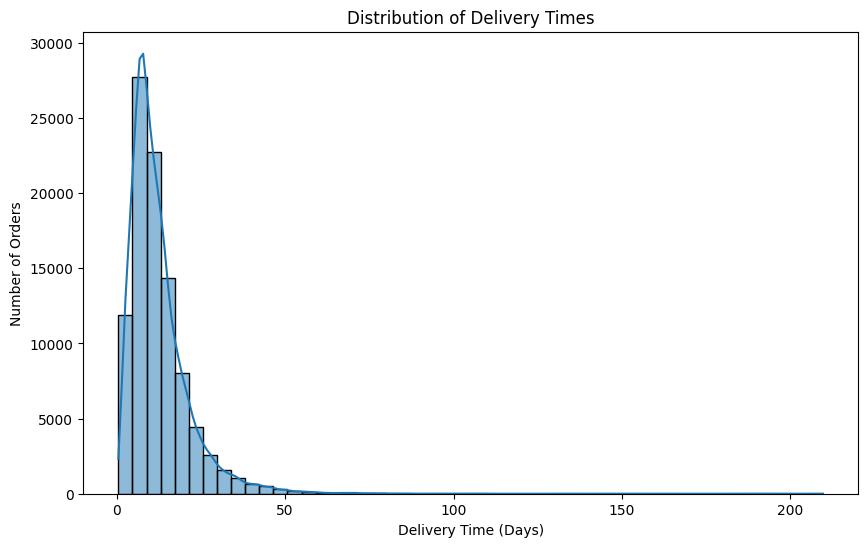

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    delivered_orders["delivery_time_days"],
    bins=50,
    kde=True
)

plt.title("Distribution of Delivery Times")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()

In [6]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

print("Date columns converted successfully.")
print(orders[date_columns].dtypes)

Date columns converted successfully.
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [7]:
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].notna())
].copy()

print("Delivered-order analysis dataset recreated successfully.")
print("Usable delivered orders:", len(delivered_orders))

Delivered-order analysis dataset recreated successfully.
Usable delivered orders: 96470


In [8]:
# Step 7.22 — Restore delivery-time and delay calculations

# Actual delivery time (in days)
delivered_orders['delivery_time_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

# Estimated delivery time (in days)
delivered_orders['estimated_delivery_time_days'] = (
    delivered_orders['order_estimated_delivery_date']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / (24 * 60 * 60)

# Delivery delay (actual - estimated)
delivered_orders['delivery_delay_days'] = (
    delivered_orders['delivery_time_days']
    - delivered_orders['estimated_delivery_time_days']
)

print("Delivery-time and delay calculations restored successfully.")
print(delivered_orders[
    ['delivery_time_days',
     'estimated_delivery_time_days',
     'delivery_delay_days']
].describe())

Delivery-time and delay calculations restored successfully.
       delivery_time_days  estimated_delivery_time_days  delivery_delay_days
count        96470.000000                  96470.000000         96470.000000
mean            12.558217                     23.736343           -11.178126
std              9.546156                      8.761052            10.184354
min              0.533414                      2.008009          -146.016123
25%              6.766204                     18.329905           -16.244065
50%             10.217477                     23.230880           -11.948102
75%             15.720182                     28.407795            -6.389815
max            209.628611                    155.135463           188.975081


In [9]:
# Step 7.23 — Check delivery performance

print("Delivery performance summary:")
print(delivered_orders[
    ['delivery_time_days',
     'estimated_delivery_time_days',
     'delivery_delay_days']
].describe())

print("\nMissing values:")
print(delivered_orders[
    ['delivery_time_days',
     'estimated_delivery_time_days',
     'delivery_delay_days']
].isna().sum())

Delivery performance summary:
       delivery_time_days  estimated_delivery_time_days  delivery_delay_days
count        96470.000000                  96470.000000         96470.000000
mean            12.558217                     23.736343           -11.178126
std              9.546156                      8.761052            10.184354
min              0.533414                      2.008009          -146.016123
25%              6.766204                     18.329905           -16.244065
50%             10.217477                     23.230880           -11.948102
75%             15.720182                     28.407795            -6.389815
max            209.628611                    155.135463           188.975081

Missing values:
delivery_time_days              0
estimated_delivery_time_days    0
delivery_delay_days             0
dtype: int64


In [10]:
# Step 7.24 — Calculate core logistics KPIs

total_delivered_orders = len(delivered_orders)

on_time_orders = (
    delivered_orders['delivery_delay_days'] <= 0
).sum()

late_orders = (
    delivered_orders['delivery_delay_days'] > 0
).sum()

average_delivery_time = delivered_orders['delivery_time_days'].mean()

average_delivery_delay = delivered_orders['delivery_delay_days'].mean()

on_time_rate = (on_time_orders / total_delivered_orders) * 100

late_delivery_rate = (late_orders / total_delivered_orders) * 100

print("Core Logistics KPIs")
print("-" * 30)
print(f"Total delivered orders: {total_delivered_orders:,}")
print(f"Average delivery time: {average_delivery_time:.2f} days")
print(f"On-time delivery rate: {on_time_rate:.2f}%")
print(f"Late delivery rate: {late_delivery_rate:.2f}%")
print(f"Average delivery delay: {average_delivery_delay:.2f} days")

Core Logistics KPIs
------------------------------
Total delivered orders: 96,470
Average delivery time: 12.56 days
On-time delivery rate: 91.89%
Late delivery rate: 8.11%
Average delivery delay: -11.18 days


In [11]:
# Step 7.25 — Categorize delivery performance

delivered_orders['delivery_status'] = delivered_orders[
    'delivery_delay_days'
].apply(
    lambda x: 'Late' if x > 0
    else ('On Time' if x == 0 else 'Early')
)

delivery_status_counts = delivered_orders['delivery_status'].value_counts()

print("Delivery Performance Categories")
print("-" * 35)
print(delivery_status_counts)

print("\nPercentage distribution:")
print(
    (delivery_status_counts / len(delivered_orders) * 100)
    .round(2)
)

Delivery Performance Categories
-----------------------------------
delivery_status
Early    88644
Late      7826
Name: count, dtype: int64

Percentage distribution:
delivery_status
Early    91.89
Late      8.11
Name: count, dtype: float64


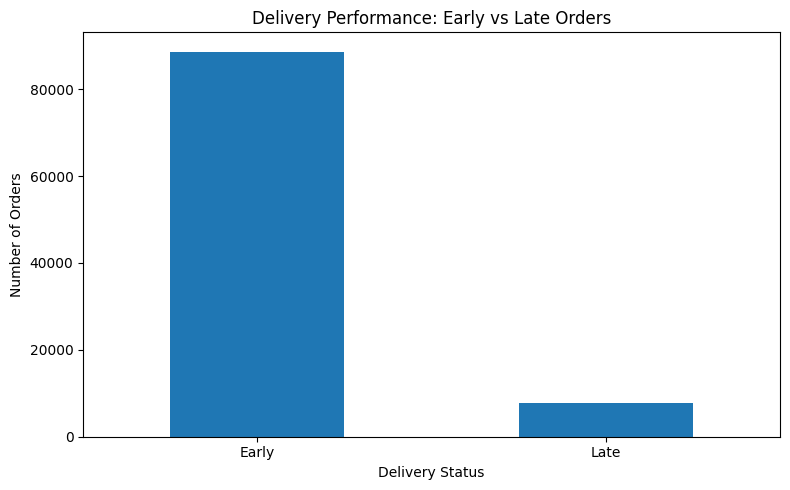

In [12]:
# Step 7.26 — Delivery performance visualization

import matplotlib.pyplot as plt

status_counts = delivered_orders['delivery_status'].value_counts()

plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar')

plt.title('Delivery Performance: Early vs Late Orders')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
# Step 7.27 — Analyze late-delivery severity

late_orders = delivered_orders[
    delivered_orders['delivery_delay_days'] > 0
].copy()

print("Late Delivery Analysis")
print("-" * 30)
print(f"Number of late orders: {len(late_orders):,}")
print(
    f"Average delay among late orders: "
    f"{late_orders['delivery_delay_days'].mean():.2f} days"
)
print(
    f"Median delay among late orders: "
    f"{late_orders['delivery_delay_days'].median():.2f} days"
)
print(
    f"Maximum delay: "
    f"{late_orders['delivery_delay_days'].max():.2f} days"
)

print("\nLate-delay statistics:")
print(
    late_orders['delivery_delay_days']
    .describe()
)

Late Delivery Analysis
------------------------------
Number of late orders: 7,826
Average delay among late orders: 9.55 days
Median delay among late orders: 5.81 days
Maximum delay: 188.98 days

Late-delay statistics:
count    7826.000000
mean        9.551776
std        13.952540
min         0.002500
25%         1.867179
50%         5.806481
75%        11.820978
max       188.975081
Name: delivery_delay_days, dtype: float64


In [14]:
# Step 7.28 — Classify late deliveries by severity

late_orders['delay_severity'] = pd.cut(
    late_orders['delivery_delay_days'],
    bins=[0, 3, 7, 14, float('inf')],
    labels=[
        'Minor (0–3 days)',
        'Moderate (3–7 days)',
        'High (7–14 days)',
        'Severe (>14 days)'
    ],
    include_lowest=True
)

severity_counts = late_orders['delay_severity'].value_counts(
    sort=False
)

severity_percent = (
    severity_counts / len(late_orders) * 100
).round(2)

print("Late Delivery Severity")
print("-" * 30)

for category in severity_counts.index:
    print(
        f"{category}: "
        f"{severity_counts[category]:,} orders "
        f"({severity_percent[category]:.2f}%)"
    )

Late Delivery Severity
------------------------------
Minor (0–3 days): 2,662 orders (34.01%)
Moderate (3–7 days): 1,819 orders (23.24%)
High (7–14 days): 1,790 orders (22.87%)
Severe (>14 days): 1,555 orders (19.87%)


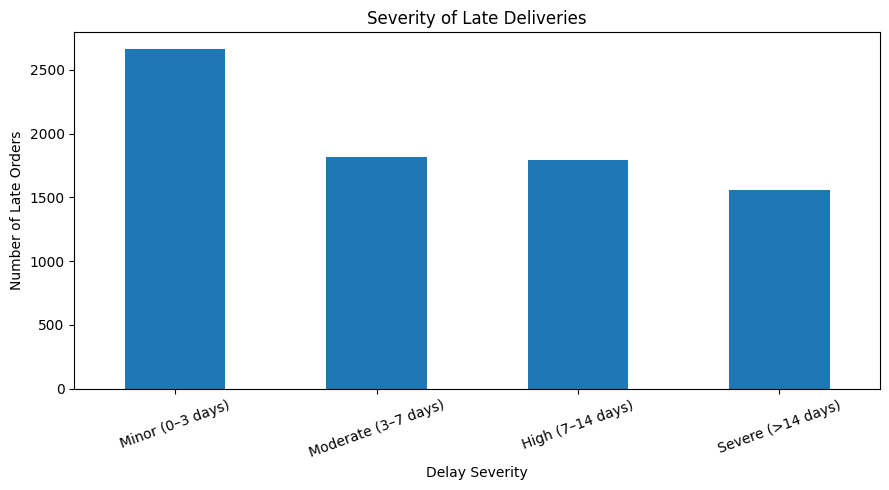

In [15]:
# Step 7.29 — Visualize late-delivery severity

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

severity_counts.plot(kind='bar')

plt.title('Severity of Late Deliveries')
plt.xlabel('Delay Severity')
plt.ylabel('Number of Late Orders')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [17]:
# Step 7.30 — Check available columns

print("Columns in delivered_orders:")
print(delivered_orders.columns.tolist())

Columns in delivered_orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time_days', 'estimated_delivery_time_days', 'delivery_delay_days', 'delivery_status']


In [18]:
# Step 7.30 — Analyze delivery time distribution

print("Delivery Time Distribution")
print("-" * 35)

print(
    delivered_orders['delivery_time_days'].describe().round(2)
)

print("\nDelivery Time Percentiles")
print("-" * 35)

percentiles = delivered_orders['delivery_time_days'].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95]
)

print(percentiles.round(2))

Delivery Time Distribution
-----------------------------------
count    96470.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63
Name: delivery_time_days, dtype: float64

Delivery Time Percentiles
-----------------------------------
0.25     6.77
0.50    10.22
0.75    15.72
0.90    23.10
0.95    29.27
Name: delivery_time_days, dtype: float64


In [19]:
# Step 7.31 — Identify extremely long deliveries

long_delivery_orders = delivered_orders[
    delivered_orders['delivery_time_days'] > 30
].copy()

long_delivery_count = len(long_delivery_orders)

long_delivery_percentage = (
    long_delivery_count / len(delivered_orders) * 100
)

print("Extremely Long Delivery Analysis")
print("-" * 40)
print(f"Orders taking more than 30 days: {long_delivery_count:,}")
print(f"Percentage of delivered orders: {long_delivery_percentage:.2f}%")

print("\nDelivery time statistics for >30-day deliveries:")
print(
    long_delivery_orders['delivery_time_days']
    .describe()
    .round(2)
)

Extremely Long Delivery Analysis
----------------------------------------
Orders taking more than 30 days: 4,550
Percentage of delivered orders: 4.72%

Delivery time statistics for >30-day deliveries:
count    4550.00
mean       41.64
std        16.50
min        30.00
25%        32.98
50%        37.03
75%        44.44
max       209.63
Name: delivery_time_days, dtype: float64


In [20]:
# Step 7.32 — Monthly delivery performance analysis

# Extract purchase month
delivered_orders['purchase_month'] = (
    delivered_orders['order_purchase_timestamp']
    .dt.to_period('M')
)

monthly_delivery = delivered_orders.groupby(
    'purchase_month'
).agg(
    total_orders=('order_id', 'count'),
    average_delivery_time=('delivery_time_days', 'mean'),
    average_delay=('delivery_delay_days', 'mean'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
)

# Calculate late delivery rate
monthly_delivery['late_delivery_rate'] = (
    monthly_delivery['late_orders']
    / monthly_delivery['total_orders']
    * 100
)

print("Monthly Delivery Performance")
print("-" * 40)

print(
    monthly_delivery[
        [
            'total_orders',
            'average_delivery_time',
            'average_delay',
            'late_delivery_rate'
        ]
    ].round(2)
)

Monthly Delivery Performance
----------------------------------------
                total_orders  average_delivery_time  average_delay  \
purchase_month                                                       
2016-09                    1                  54.81          36.32   
2016-10                  265                  19.60         -36.08   
2016-12                    1                   4.69         -21.34   
2017-01                  750                  12.65         -26.86   
2017-02                 1653                  13.17         -18.68   
2017-03                 2546                  12.95         -11.78   
2017-04                 2303                  14.92         -12.43   
2017-05                 3545                  11.32         -12.96   
2017-06                 3135                  12.01         -12.01   
2017-07                 3872                  11.59         -11.72   
2017-08                 4193                  11.15         -12.33   
2017-09             

In [21]:
# Step 7.33 — Identify worst-performing months

# Consider only months with at least 500 orders
reliable_months = monthly_delivery[
    monthly_delivery['total_orders'] >= 500
].copy()

# Sort by late delivery rate
worst_months = reliable_months.sort_values(
    'late_delivery_rate',
    ascending=False
)

print("Worst-Performing Months")
print("-" * 35)

print(
    worst_months[
        [
            'total_orders',
            'average_delivery_time',
            'average_delay',
            'late_delivery_rate'
        ]
    ].head(10).round(2)
)

Worst-Performing Months
-----------------------------------
                total_orders  average_delivery_time  average_delay  \
purchase_month                                                       
2018-03                 7003                  16.30          -5.73   
2018-02                 6555                  16.95          -7.58   
2017-11                 7288                  15.16          -7.40   
2018-08                 6351                   7.73          -7.45   
2017-12                 5513                  15.39         -12.29   
2018-05                 6749                  11.42         -11.47   
2017-04                 2303                  14.92         -12.43   
2018-01                 7069                  14.08         -12.22   
2017-03                 2546                  12.95         -11.78   
2018-04                 6798                  11.50         -12.18   

                late_delivery_rate  
purchase_month                      
2018-03                  

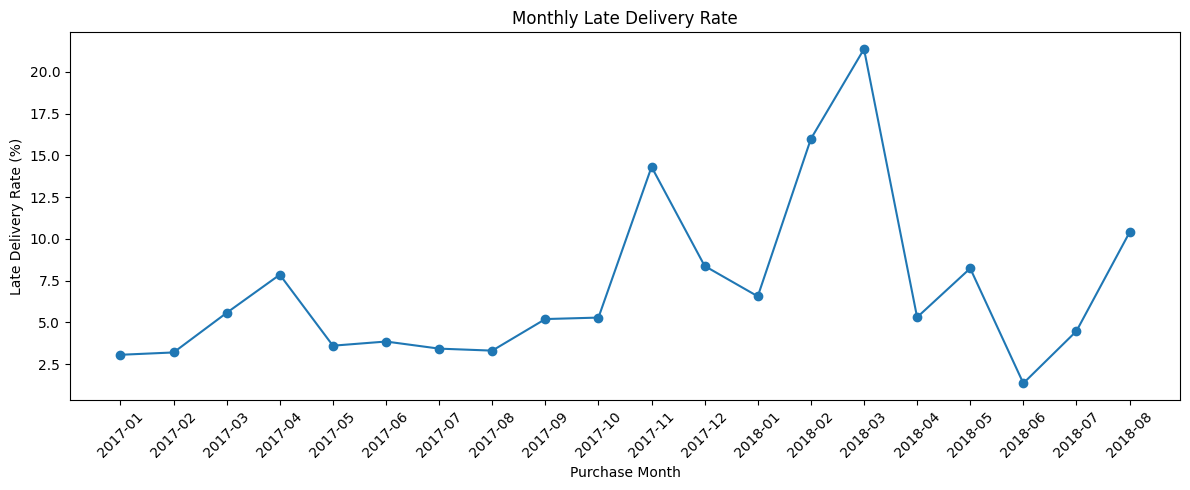

In [22]:
# Step 7.34 — Visualize monthly late-delivery rate

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

monthly_rate = reliable_months.sort_index()

plt.plot(
    monthly_rate.index.astype(str),
    monthly_rate['late_delivery_rate'],
    marker='o'
)

plt.title('Monthly Late Delivery Rate')
plt.xlabel('Purchase Month')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Step 7.35 — Yearly delivery performance analysis

# Extract purchase year
delivered_orders['purchase_year'] = (
    delivered_orders['order_purchase_timestamp']
    .dt.year
)

yearly_delivery = delivered_orders.groupby(
    'purchase_year'
).agg(
    total_orders=('order_id', 'count'),
    average_delivery_time=('delivery_time_days', 'mean'),
    average_delay=('delivery_delay_days', 'mean'),
    late_orders=('delivery_status', lambda x: (x == 'Late').sum())
)

# Calculate late delivery rate
yearly_delivery['late_delivery_rate'] = (
    yearly_delivery['late_orders']
    / yearly_delivery['total_orders']
    * 100
)

print("Yearly Delivery Performance")
print("-" * 40)

print(
    yearly_delivery[
        [
            'total_orders',
            'average_delivery_time',
            'average_delay',
            'late_delivery_rate'
        ]
    ].round(2)
)

Yearly Delivery Performance
----------------------------------------
               total_orders  average_delivery_time  average_delay  \
purchase_year                                                       
2016                    267                  19.68         -35.75   
2017                  43426                  13.03         -11.65   
2018                  52777                  12.14         -10.66   

               late_delivery_rate  
purchase_year                      
2016                         1.50  
2017                         6.63  
2018                         9.37  


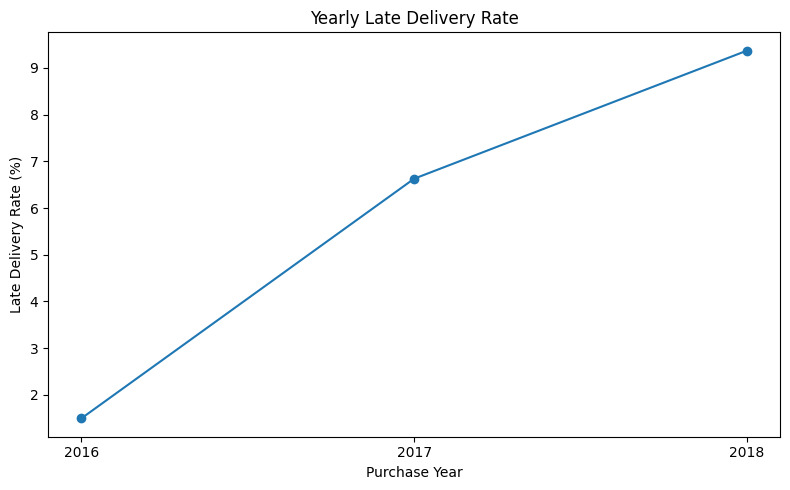

In [24]:
# Step 7.36 — Visualize yearly late-delivery rate

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    yearly_delivery.index.astype(str),
    yearly_delivery['late_delivery_rate'],
    marker='o'
)

plt.title('Yearly Late Delivery Rate')
plt.xlabel('Purchase Year')
plt.ylabel('Late Delivery Rate (%)')

plt.tight_layout()
plt.show()

In [25]:
# Step 7.37 — Analyze order processing time

delivered_orders['approval_time_hours'] = (
    delivered_orders['order_approved_at']
    - delivered_orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

print("Order Processing Time Analysis")
print("-" * 40)

print(
    delivered_orders['approval_time_hours']
    .describe()
    .round(2)
)

Order Processing Time Analysis
----------------------------------------
count    96456.00
mean        10.28
std         20.54
min          0.00
25%          0.22
50%          0.34
75%         14.52
max        741.44
Name: approval_time_hours, dtype: float64


In [26]:
# Step 7.38 — Identify high-risk order processing delays

high_processing_orders = delivered_orders[
    delivered_orders['approval_time_hours'] > 24
].copy()

print("High Processing Time Analysis")
print("-" * 40)

print(
    f"Orders taking more than 24 hours to approve: "
    f"{len(high_processing_orders):,}"
)

print(
    f"Percentage of delivered orders: "
    f"{len(high_processing_orders) / len(delivered_orders) * 100:.2f}%"
)

print("\nProcessing time statistics for these orders:")
print(
    high_processing_orders['approval_time_hours']
    .describe()
    .round(2)
)

High Processing Time Analysis
----------------------------------------
Orders taking more than 24 hours to approve: 16,873
Percentage of delivered orders: 17.49%

Processing time statistics for these orders:
count    16873.00
mean        45.54
std         27.16
min         24.00
25%         29.09
50%         36.97
75%         53.30
max        741.44
Name: approval_time_hours, dtype: float64


In [27]:
# Step 7.39 — Analyze carrier handling time

delivered_orders['carrier_handling_time_days'] = (
    delivered_orders['order_delivered_carrier_date']
    - delivered_orders['order_approved_at']
).dt.total_seconds() / (24 * 60 * 60)

print("Carrier Handling Time Analysis")
print("-" * 40)

print(
    delivered_orders['carrier_handling_time_days']
    .describe()
    .round(2)
)

Carrier Handling Time Analysis
----------------------------------------
count    96455.00
mean         2.80
std          3.54
min       -171.22
25%          0.87
50%          1.82
75%          3.57
max        125.76
Name: carrier_handling_time_days, dtype: float64


In [28]:
# Step 7.40 — Check invalid carrier handling times

invalid_carrier_times = delivered_orders[
    delivered_orders['carrier_handling_time_days'] < 0
].copy()

print("Invalid Carrier Handling Time Analysis")
print("-" * 40)

print(
    f"Orders with negative carrier handling time: "
    f"{len(invalid_carrier_times):,}"
)

print(
    f"Percentage of delivered orders: "
    f"{len(invalid_carrier_times) / len(delivered_orders) * 100:.2f}%"
)

print("\nNegative handling time statistics:")
print(
    invalid_carrier_times['carrier_handling_time_days']
    .describe()
    .round(2)
)

Invalid Carrier Handling Time Analysis
----------------------------------------
Orders with negative carrier handling time: 1,350
Percentage of delivered orders: 1.40%

Negative handling time statistics:
count    1350.00
mean       -1.03
std         4.82
min      -171.22
25%        -1.08
50%        -0.71
75%        -0.06
max        -0.00
Name: carrier_handling_time_days, dtype: float64


In [29]:
# Step 7.41 — Analyze valid carrier handling times

valid_carrier_orders = delivered_orders[
    delivered_orders['carrier_handling_time_days'] >= 0
].copy()

print("Valid Carrier Handling Time Analysis")
print("-" * 40)

print(
    f"Valid orders: {len(valid_carrier_orders):,}"
)

print(
    f"Average carrier handling time: "
    f"{valid_carrier_orders['carrier_handling_time_days'].mean():.2f} days"
)

print(
    f"Median carrier handling time: "
    f"{valid_carrier_orders['carrier_handling_time_days'].median():.2f} days"
)

print("\nValid carrier handling time statistics:")
print(
    valid_carrier_orders['carrier_handling_time_days']
    .describe()
    .round(2)
)

Valid Carrier Handling Time Analysis
----------------------------------------
Valid orders: 95,105
Average carrier handling time: 2.85 days
Median carrier handling time: 1.85 days

Valid carrier handling time statistics:
count    95105.00
mean         2.85
std          3.49
min          0.00
25%          0.90
50%          1.85
75%          3.62
max        125.76
Name: carrier_handling_time_days, dtype: float64


In [31]:
# Step 7.42 — Analyze major delivery stages

valid_stage_orders = delivered_orders[
    (delivered_orders['carrier_handling_time_days'] >= 0)
].copy()

valid_stage_orders['carrier_to_customer_days'] = (
    valid_stage_orders['order_delivered_customer_date']
    - valid_stage_orders['order_delivered_carrier_date']
).dt.total_seconds() / (24 * 60 * 60)

print("Delivery Stage Analysis")
print("-" * 40)

print("\n1. Approval → Carrier Handover")
print(
    f"Average: "
    f"{valid_stage_orders['carrier_handling_time_days'].mean():.2f} days"
)
print(
    f"Median: "
    f"{valid_stage_orders['carrier_handling_time_days'].median():.2f} days"
)

print("\n2. Carrier Handover → Customer Delivery")
print(
    f"Average: "
    f"{valid_stage_orders['carrier_to_customer_days'].mean():.2f} days"
)
print(
    f"Median: "
    f"{valid_stage_orders['carrier_to_customer_days'].median():.2f} days"
)

print("\n3. Purchase → Customer Delivery")
print(
    f"Average: "
    f"{valid_stage_orders['delivery_time_days'].mean():.2f} days"
)
print(
    f"Median: "
    f"{valid_stage_orders['delivery_time_days'].median():.2f} days"
)

Delivery Stage Analysis
----------------------------------------

1. Approval → Carrier Handover
Average: 2.85 days
Median: 1.85 days

2. Carrier Handover → Customer Delivery
Average: 9.36 days
Median: 7.11 days

3. Purchase → Customer Delivery
Average: 12.62 days
Median: 10.27 days


In [32]:
# Step 7.43 — Correlation analysis

correlation_data = valid_stage_orders[
    [
        'approval_time_hours',
        'carrier_handling_time_days',
        'carrier_to_customer_days',
        'delivery_time_days'
    ]
].corr()

print("Correlation Analysis")
print("-" * 40)

print(
    correlation_data.round(2)
)

Correlation Analysis
----------------------------------------
                            approval_time_hours  carrier_handling_time_days  \
approval_time_hours                        1.00                       -0.01   
carrier_handling_time_days                -0.01                        1.00   
carrier_to_customer_days                   0.02                        0.03   
delivery_time_days                         0.10                        0.39   

                            carrier_to_customer_days  delivery_time_days  
approval_time_hours                             0.02                0.10  
carrier_handling_time_days                      0.03                0.39  
carrier_to_customer_days                        1.00                0.93  
delivery_time_days                              0.93                1.00  


In [33]:
# Step 7.44 — Prepare predictive modeling dataset

model_data = valid_stage_orders[
    [
        'approval_time_hours',
        'carrier_handling_time_days',
        'carrier_to_customer_days',
        'delivery_time_days'
    ]
].dropna().copy()

print("Predictive Modeling Dataset")
print("-" * 40)

print(f"Rows: {len(model_data):,}")
print(f"Columns: {len(model_data.columns)}")

print("\nColumns:")
print(model_data.columns.tolist())

print("\nMissing values:")
print(model_data.isnull().sum())

Predictive Modeling Dataset
----------------------------------------
Rows: 95,105
Columns: 4

Columns:
['approval_time_hours', 'carrier_handling_time_days', 'carrier_to_customer_days', 'delivery_time_days']

Missing values:
approval_time_hours           0
carrier_handling_time_days    0
carrier_to_customer_days      0
delivery_time_days            0
dtype: int64


In [34]:
# Step 7.45 — Build Linear Regression Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features and target
X = model_data[
    [
        'approval_time_hours',
        'carrier_handling_time_days',
        'carrier_to_customer_days'
    ]
]

y = model_data['delivery_time_days']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Create and train the model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

print("Linear Regression Model")
print("-" * 40)

print(f"Training records: {len(X_train):,}")
print(f"Testing records: {len(X_test):,}")

print("\nModel trained successfully.")

Linear Regression Model
----------------------------------------
Training records: 76,084
Testing records: 19,021

Model trained successfully.


In [35]:
# Step 7.46 — Evaluate Linear Regression Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation")
print("-" * 40)

print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} days")
print(f"R² Score: {r2:.4f}")

Linear Regression Model Evaluation
----------------------------------------
Mean Absolute Error (MAE): 0.00 days
Root Mean Squared Error (RMSE): 0.00 days
R² Score: 1.0000


In [36]:
# Step 7.47 — Rebuild model without target leakage

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features available before final delivery
X_realistic = model_data[
    [
        'approval_time_hours',
        'carrier_handling_time_days'
    ]
]

# Target
y_realistic = model_data['delivery_time_days']

# Train-test split
X_train_realistic, X_test_realistic, y_train_realistic, y_test_realistic = train_test_split(
    X_realistic,
    y_realistic,
    test_size=0.20,
    random_state=42
)

# Train model
realistic_model = LinearRegression()
realistic_model.fit(X_train_realistic, y_train_realistic)

# Predictions
y_pred_realistic = realistic_model.predict(X_test_realistic)

# Evaluation
mae_realistic = mean_absolute_error(
    y_test_realistic,
    y_pred_realistic
)

rmse_realistic = np.sqrt(
    mean_squared_error(
        y_test_realistic,
        y_pred_realistic
    )
)

r2_realistic = r2_score(
    y_test_realistic,
    y_pred_realistic
)

print("Realistic Linear Regression Model")
print("-" * 40)

print(f"MAE: {mae_realistic:.2f} days")
print(f"RMSE: {rmse_realistic:.2f} days")
print(f"R² Score: {r2_realistic:.4f}")

Realistic Linear Regression Model
----------------------------------------
MAE: 5.77 days
RMSE: 8.93 days
R² Score: 0.1726


In [37]:
# Step 7.48 — Examine Linear Regression coefficients

coefficients = pd.DataFrame({
    'Feature': X_realistic.columns,
    'Coefficient': realistic_model.coef_
})

print("Model Coefficients")
print("-" * 40)

print(coefficients.round(4))

print("\nIntercept:")
print(round(realistic_model.intercept_, 4))

Model Coefficients
----------------------------------------
                      Feature  Coefficient
0         approval_time_hours       0.0506
1  carrier_handling_time_days       1.0732

Intercept:
9.0293


In [38]:
# Step 7.49 — Final predictive model summary

print("FINAL PREDICTIVE MODEL SUMMARY")
print("=" * 50)

print(f"Training records: {len(X_train_realistic):,}")
print(f"Testing records: {len(X_test_realistic):,}")

print("\nModel Performance")
print("-" * 50)
print(f"MAE:  {mae_realistic:.2f} days")
print(f"RMSE: {rmse_realistic:.2f} days")
print(f"R²:   {r2_realistic:.4f}")

print("\nModel Coefficients")
print("-" * 50)

for feature, coefficient in zip(
    X_realistic.columns,
    realistic_model.coef_
):
    print(f"{feature}: {coefficient:.4f}")

print(f"\nIntercept: {realistic_model.intercept_:.4f}")

print("\nKey Finding:")
print("Carrier handling time has a stronger relationship")
print("with total delivery time than approval time.")

FINAL PREDICTIVE MODEL SUMMARY
Training records: 76,084
Testing records: 19,021

Model Performance
--------------------------------------------------
MAE:  5.77 days
RMSE: 8.93 days
R²:   0.1726

Model Coefficients
--------------------------------------------------
approval_time_hours: 0.0506
carrier_handling_time_days: 1.0732

Intercept: 9.0293

Key Finding:
Carrier handling time has a stronger relationship
with total delivery time than approval time.


In [40]:
# Step 7.50 — Final Analysis Summary

print("YUVA INTERNS TASK 1 - LOGISTICS ANALYSIS")
print("=" * 60)

print("\nKEY BUSINESS KPIs")
print("-" * 60)
print(f"Delivered orders: {total_delivered_orders:,}")
print(f"Average delivery time: {average_delivery_time:.2f} days")
print(f"Delivered by estimated date: {on_time_rate:.2f}%")
print(f"Late delivery rate: {late_delivery_rate:.2f}%")
print(f"Late orders: {len(late_orders):,}")

print("\nDELIVERY RISK")
print("-" * 60)
print(
    f"Average delay among late orders: "
    f"{late_orders['delivery_delay_days'].mean():.2f} days"
)
print(
    f"Severely delayed orders (>14 days): "
    f"{(late_orders['delivery_delay_days'] > 14).sum():,}"
)
print(f"Orders taking >30 days: {len(long_delivery_orders):,}")

print("\nDELIVERY STAGES")
print("-" * 60)
print(
    f"Approval → Carrier: "
    f"{valid_carrier_orders['carrier_handling_time_days'].mean():.2f} days"
)
print(
    f"Carrier → Customer: "
    f"{valid_stage_orders['carrier_to_customer_days'].mean():.2f} days"
)
print(
    f"Total Purchase → Customer: "
    f"{valid_stage_orders['delivery_time_days'].mean():.2f} days"
)

print("\nPREDICTIVE MODEL")
print("-" * 60)
print(f"MAE: {mae_realistic:.2f} days")
print(f"RMSE: {rmse_realistic:.2f} days")
print(f"R²: {r2_realistic:.4f}")

print("\nFINAL BUSINESS INSIGHT")
print("-" * 60)
print("The carrier-to-customer stage is the largest contributor")
print("to total delivery time. Improving transportation and")
print("last-mile operations should therefore be a major priority.")

YUVA INTERNS TASK 1 - LOGISTICS ANALYSIS

KEY BUSINESS KPIs
------------------------------------------------------------
Delivered orders: 96,470
Average delivery time: 12.56 days
Delivered by estimated date: 91.89%
Late delivery rate: 8.11%
Late orders: 7,826

DELIVERY RISK
------------------------------------------------------------
Average delay among late orders: 9.55 days
Severely delayed orders (>14 days): 1,555
Orders taking >30 days: 4,550

DELIVERY STAGES
------------------------------------------------------------
Approval → Carrier: 2.85 days
Carrier → Customer: 9.36 days
Total Purchase → Customer: 12.62 days

PREDICTIVE MODEL
------------------------------------------------------------
MAE: 5.77 days
RMSE: 8.93 days
R²: 0.1726

FINAL BUSINESS INSIGHT
------------------------------------------------------------
The carrier-to-customer stage is the largest contributor
to total delivery time. Improving transportation and
last-mile operations should therefore be a major priorit